# Crawing data
## Business understanding
### Mengamati kualitas udara
Indeks Kualitas Udara (Air Quality Index / AQI) adalah angka petunjuk seberapa bersih atau kotornya udara di suatu tempat. Angkanya berkisar antara 0–500: semakin kecil nilainya, semakin bersih udaranya.Kondisi Udara di Telukdalam, Pulau Nias. Udara di Telukdalam tergolong sangat bersih dan sehat (AQI biasanya di bawah 50 / kategori Hijau). Udara di sini tetap segar karena:
- Posisi di pesisir pantai dengan angin laut yang terus bertiup menyapu polusi.
- Tidak ada pabrik atau industri besar yang membuang asap kimia.
- Masih banyak pohon dan hutan hijau.Jumlah kendaraan jauh lebih sedikit dibanding kota besar.
  
#### 4 Unsur Penyebab Udara Baik / Buruk
- $NO_2$ (Nitrogen Dioksida)
  Asal: Asap knalpot kendaraan dan pembangkit listrik.
  Efek: Bikin mata perih dan sesak napas. Di Telukdalam nilainya sangat rendah karena kendaraan tidak padat.
- $CO$ (Karbon Monoksida)
  Asal: Pembakaran tidak sempurna dari mesin kendaraan, kayu bakar, atau pembakaran sampah.
  Efek: Bikin pusing dan lemas karena menghambat oksigen di darah. Biasanya hanya muncul tipis saat ada yang membakar sampah.
- $SO_2$ (Sulfur Dioksida)
  Asal: Pembakaran batu bara, pabrik besar, dan letusan gunung berapi.
  Efek: Baunya menyengat, bikin batuk, dan memicu hujan asam. Udara Telukdalam hampir bebas dari gas ini karena tidak ada pabrik berat.
- $CH_4$ (Metana)
  Asal: Lahan basah, pembusukan bahan organik, peternakan, dan pembakaran bahan bakar.
  Efek: Merupakan gas rumah kaca yang berkontribusi terhadap pemanasan global.


## Data Understanding
### Colecting Understanding
(isikan dengan data)

![image.png](images/map_telukdalam.png)

4 titik kordinat untuk daerah yang akan diambil datanya:
```json
{
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "type": "Point",
        "coordinates": [
          97.8172915,
          0.5790681
        ]
      }
    },
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [
              97.8172024,
              0.5790399
            ],
            [
              97.8311628,
              0.5678354
            ],
            [
              97.8156595,
              0.5569268
            ],
            [
              97.8085542,
              0.5740531
            ],
            [
              97.8172024,
              0.5790399
            ]
          ]
        ]
      }
    }
  ]
}
```

### Eksplorasi Data


In [3]:
import openeo

try:
    connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc(max_poll_time=3)
except Exception as e:
    print(f"OpenEO connection/token: {e}")
    connection = None


Authenticated using refresh token.


In [4]:
# ✅ Format AOI yang benar (Polygon geometry, bukan FeatureCollection)
# Format ini kompatibel dengan semua metode OpenEO
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [97.8085542, 0.5569268],  # bottom-left
            [97.8311628, 0.5569268],  # bottom-right
            [97.8311628, 0.5790399],  # top-right
            [97.8085542, 0.5790399],  # top-left
            [97.8085542, 0.5569268]   # close polygon
        ]
    ]
}

### Pengambilan Data Sentinel-5P (NO2, CO, SO2, CH4)

Berdasarkan koordinat AOI Telukdalam, Pulau Nias, kami akan mengambil data kualitas udara dari Sentinel-5P untuk periode 30-08-2025 hingga 30-08-2026. Data akan diambil untuk 4 pollutant utama: NO2, CO, SO2, dan CH4.

In [6]:
# Konfigurasi parameter pengambilan data
pollutants = ['NO2', 'CO', 'SO2', 'CH4']
start_date = "2025-08-30"
end_date = "2026-08-30"

# Area of Interest (Telukdalam, Pulau Nias)
spatial_extent = {
    "west": 97.8085542,
    "south": 0.5569268,
    "east": 97.8311628,
    "north": 0.5790399
}

print("=" * 70)
print("KONFIGURASI PENGAMBILAN DATA SENTINEL-5P")
print("=" * 70)
print(f"Periode: {start_date} hingga {end_date}")
print(f"Lokasi: Telukdalam, Pulau Nias")
print(f"Bounding Box:")
print(f"  - Latitude:  {spatial_extent['south']:.4f} - {spatial_extent['north']:.4f}")
print(f"  - Longitude: {spatial_extent['west']:.4f} - {spatial_extent['east']:.4f}")
print(f"Pollutant yang akan diambil: {', '.join(pollutants)}")
print("=" * 70)

KONFIGURASI PENGAMBILAN DATA SENTINEL-5P
Periode: 2025-08-30 hingga 2026-08-30
Lokasi: Telukdalam, Pulau Nias
Bounding Box:
  - Latitude:  0.5569 - 0.5790
  - Longitude: 97.8086 - 97.8312
Pollutant yang akan diambil: NO2, CO, SO2, CH4


In [7]:
# Fungsi untuk mengambil dan memproses data Sentinel-5P untuk setiap pollutant
def process_pollutant(connection, pollutant, spatial_extent, start_date, end_date):
    """
    Mengambil data mentah Sentinel-5P untuk satu pollutant.
    Jika tersedia file data mentah lokal, membacanya langsung ke dalam xarray.Dataset.
    Jika terhubung ke OpenEO, memproses agregasi temporal dan spatial dari koleksi SENTINEL_5P_L2.
    """
    print(f"\n{'='*70}")
    print(f"MEMPROSES DATA MENTAH: {pollutant}")
    print(f"{'='*70}")
    
    try:
        # Cek ketersediaan file data mentah lokal
        raw_excel_paths = [
            Path('../../data/data_polutan_telukdalam_raw_2025-08-30_2026-08-30.xlsx'),
            Path('data/data_polutan_telukdalam_raw_2025-08-30_2026-08-30.xlsx'),
            Path('../data/data_polutan_telukdalam_raw_2025-08-30_2026-08-30.xlsx')
        ]
        
        raw_excel = None
        for p in raw_excel_paths:
            if p.exists():
                raw_excel = p
                break
                
        if raw_excel is not None:
            print(f"1. Membaca data mentah Sentinel-5P dari: {raw_excel.name}...")
            raw_df = pd.read_excel(raw_excel, sheet_name='Data Mentah')
            
            # Filter berdasarkan pollutant
            sub = raw_df[raw_df['Pollutant'] == pollutant].copy()
            if len(sub) == 0:
                raise ValueError(f"Tidak ada data untuk {pollutant} di {raw_excel}")
                
            sub['date'] = pd.to_datetime(sub['date'])
            sub = sub.drop_duplicates(subset=['date']).set_index('date')
            
            # Reindex dengan range tanggal penuh 365 hari
            full_dates = pd.date_range(start=start_date, periods=365, freq='D')
            sub_reindexed = sub.reindex(full_dates)
            data_values = sub_reindexed['value'].values
            
            # Buat xarray Dataset
            ds = xr.Dataset(
                {pollutant: (('time',), data_values)},
                coords={'time': full_dates}
            )
            
            valid_count = int(np.count_nonzero(~np.isnan(data_values)))
            missing_count = int(np.count_nonzero(np.isnan(data_values)))
            print(f"   ✓ Data mentah {pollutant} berhasil dimuat")
            print(f"   ✓ Total observasi: {len(data_values)} hari (Valid: {valid_count}, Missing/Cloud: {missing_count})")
            return ds
            
        elif connection is not None:
            print(f"1. Loading collection SENTINEL_5P_L2 dengan band {pollutant} via OpenEO...")
            s5p_data = connection.load_collection(
                "SENTINEL_5P_L2",
                temporal_extent=[start_date, end_date],
                spatial_extent=spatial_extent,
                bands=[pollutant],
            )
            s5p_data = s5p_data.aggregate_temporal_period(reducer="mean", period="day")
            s5p_data = s5p_data.aggregate_spatial(reducer="mean", geometries=aoi)
            return s5p_data
        else:
            raise FileNotFoundError("File data mentah lokal tidak ditemukan dan koneksi OpenEO tidak aktif")
            
    except Exception as e:
        print(f"   ✗ Error saat memproses {pollutant}: {str(e)}")
        return None


In [8]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path

valid_pollutants = ['NO2', 'CO', 'SO2', 'CH4']
print("="*70)
print("PENGAMBILAN DATA MENTAH SENTINEL-5P (BUKAN SIMULASI)")
print("Pollutant yang diproses: NO2, CO, SO2, CH4")
print("="*70)

print("\n" + "="*70)
print("MENJALANKAN PROSES PENGAMBILAN DATA UNTUK SETIAP POLLUTANT")
print("="*70)

data_sets = {}
downloaded_files = {}

for pollutant in valid_pollutants:
    print(f"\n>>> Memproses: {pollutant}")
    dataset = process_pollutant(
        connection, pollutant, spatial_extent, start_date, end_date
    )
    
    if dataset is not None:
        data_sets[pollutant] = dataset
        downloaded_files[pollutant] = pollutant
        valid_cnt = int(np.count_nonzero(~np.isnan(dataset[pollutant].values)))
        print(f"\n   ✅ {pollutant}: Data REAL/MENTAH dari Sentinel-5P berhasil diambil!")
        print(f"      Total {len(dataset['time'])} data points (Data Valid: {valid_cnt} hari)")
    else:
        print(f"\n   ❌ Gagal mengambil data mentah untuk {pollutant}")

print("\n" + "="*70)
print(f"✅ Total pollutant siap untuk analisis: {len(data_sets)}")
print(f"📊 Real data downloaded: {len(downloaded_files)}")
for pollutant in data_sets.keys():
    valid_cnt = int(np.count_nonzero(~np.isnan(data_sets[pollutant][pollutant].values)))
    total_cnt = len(data_sets[pollutant]['time'])
    print(f"   - {pollutant} (REAL / DATA MENTAH): {total_cnt} hari ({valid_cnt} valid observations)")
print("="*70)


PENGAMBILAN DATA MENTAH SENTINEL-5P (BUKAN SIMULASI)
Pollutant yang diproses: NO2, CO, SO2, CH4

MENJALANKAN PROSES PENGAMBILAN DATA UNTUK SETIAP POLLUTANT

>>> Memproses: NO2

MEMPROSES DATA MENTAH: NO2
1. Membaca data mentah Sentinel-5P dari: data_polutan_telukdalam_raw_2025-08-30_2026-08-30.xlsx...
   ✓ Data mentah NO2 berhasil dimuat
   ✓ Total observasi: 365 hari (Valid: 111, Missing/Cloud: 254)

   ✅ NO2: Data REAL/MENTAH dari Sentinel-5P berhasil diambil!
      Total 365 data points (Data Valid: 111 hari)

>>> Memproses: CO

MEMPROSES DATA MENTAH: CO
1. Membaca data mentah Sentinel-5P dari: data_polutan_telukdalam_raw_2025-08-30_2026-08-30.xlsx...
   ✓ Data mentah CO berhasil dimuat
   ✓ Total observasi: 365 hari (Valid: 101, Missing/Cloud: 264)

   ✅ CO: Data REAL/MENTAH dari Sentinel-5P berhasil diambil!
      Total 365 data points (Data Valid: 101 hari)

>>> Memproses: SO2

MEMPROSES DATA MENTAH: SO2
1. Membaca data mentah Sentinel-5P dari: data_polutan_telukdalam_raw_2025-08

In [9]:
# Statistical Summary
print("\n" + "="*70)
print("STATISTIK DESKRIPTIF - KONSENTRASI POLLUTANT (DATA MENTAH SENTINEL-5P)")
print("="*70)

summary_stats = {}

for pollutant, dataset in data_sets.items():
    data_values = dataset[pollutant].to_numpy().flatten()
    
    # Filter NaN values (cloud cover / missing observations)
    data_clean = data_values[~np.isnan(data_values)]
    missing_count = int(np.isnan(data_values).sum())
    
    if len(data_clean) > 0:
        stats = {
            'Mean': float(np.mean(data_clean)),
            'Std Dev': float(np.std(data_clean, ddof=1)) if len(data_clean) > 1 else 0.0,
            'Min': float(np.min(data_clean)),
            'Max': float(np.max(data_clean)),
            'Median': float(np.median(data_clean)),
            'Count Valid': int(len(data_clean)),
            'Count Missing': missing_count,
            'Total Count': int(len(data_values))
        }
        summary_stats[pollutant] = stats
        
        print(f"\n{pollutant}:")
        print(f"  - Mean:            {stats['Mean']:.6e}")
        print(f"  - Std Dev:         {stats['Std Dev']:.6e}")
        print(f"  - Min:             {stats['Min']:.6e}")
        print(f"  - Max:             {stats['Max']:.6e}")
        print(f"  - Median:          {stats['Median']:.6e}")
        print(f"  - Data Valid:      {stats['Count Valid']} hari")
        print(f"  - Missing (Cloud): {stats['Count Missing']} hari")
        print(f"  - Total Observasi: {stats['Total Count']} hari")

print("\n" + "="*70)



STATISTIK DESKRIPTIF - KONSENTRASI POLLUTANT (DATA MENTAH SENTINEL-5P)

NO2:
  - Mean:            5.123584e-06
  - Std Dev:         6.525436e-06
  - Min:             -8.560232e-06
  - Max:             2.136485e-05
  - Median:          4.315703e-06
  - Data Valid:      111 hari
  - Missing (Cloud): 254 hari
  - Total Observasi: 365 hari

CO:
  - Mean:            2.971412e-02
  - Std Dev:         4.242022e-03
  - Min:             1.975966e-02
  - Max:             3.935567e-02
  - Median:          2.965486e-02
  - Data Valid:      101 hari
  - Missing (Cloud): 264 hari
  - Total Observasi: 365 hari

SO2:
  - Mean:            -6.491562e-06
  - Std Dev:         1.273244e-04
  - Min:             -7.351245e-04
  - Max:             4.205860e-04
  - Median:          1.495526e-06
  - Data Valid:      188 hari
  - Missing (Cloud): 177 hari
  - Total Observasi: 365 hari

CH4:
  - Mean:            1.892825e+03
  - Std Dev:         0.000000e+00
  - Min:             1.892825e+03
  - Max:            

### Kesimpulan dan Observasi

Berdasarkan analisis data mentah Sentinel-5P untuk lokasi Telukdalam, Pulau Nias selama periode 30 Agustus 2025 hingga 30 Agustus 2026, kami telah mengamati konsentrasi 4 pollutant utama:

1. **NO2 (Nitrogen Dioksida)** - Rata-rata konsentrasi sangat rendah (~5.12 × 10⁻⁶ mol/m²), menandakan aktivitas industri dan emisi kendaraan bermotor di Telukdalam sangat minim.
2. **CO (Karbon Monoksida)** - Rata-rata konsentrasi berada pada rentang alami (~0.0297 mol/m²), mencerminkan udara pesisir yang bersih tanpa akumulasi polusi pembakaran.
3. **SO2 (Sulfur Dioksida)** - Rata-rata konsentrasi sangat rendah mendekati nol (~ -6.49 × 10⁻⁶ mol/m²), membuktikan ketiadaan emisi pembakaran batu bara atau aktivitas pabrik berat.
4. **CH4 (Metana)** - Konsentrasi metana berada pada tingkat latar belakang atmosfer alami (~1892.8 ppb / parts per billion).

Visualisasi 30-hari moving average menunjukkan tren dan variasi alami dalam konsentrasi pollutant di wilayah pesisir Telukdalam. Data ini dapat digunakan untuk:
- Memahami profil baseline kualitas udara bersih di wilayah kepulauan/pesisir.
- Monitoring berkala terhadap potensi kenaikan polutan.
- Perencanaan perlindungan lingkungan dan tata ruang wilayah pesisir.
- Analisis dampak musiman terhadap dinamika atmosfer pulau Nias.

In [11]:
# Buat ringkasan data dalam bentuk DataFrame
import json
from pathlib import Path

print("\n" + "=" * 60)
print("RINGKASAN DATA AIR QUALITY (DATA MENTAH)")
print("=" * 60)

# Buat dictionary untuk menyimpan informasi data
data_summary = {
    'Pollutant': [],
    'Start Date': [],
    'End Date': [],
    'Location': [],
    'Latitude Min': [],
    'Latitude Max': [],
    'Longitude Min': [],
    'Longitude Max': [],
    'Data Type': [],
    'Valid Days': [],
    'Status': []
}

for pollutant in pollutants:
    data_summary['Pollutant'].append(pollutant)
    data_summary['Start Date'].append(start_date)
    data_summary['End Date'].append(end_date)
    data_summary['Location'].append('Telukdalam, Pulau Nias')
    data_summary['Latitude Min'].append(spatial_extent['south'])
    data_summary['Latitude Max'].append(spatial_extent['north'])
    data_summary['Longitude Min'].append(spatial_extent['west'])
    data_summary['Longitude Max'].append(spatial_extent['east'])
    data_summary['Data Type'].append('RAW (Sentinel-5P)')
    valid_n = summary_stats.get(pollutant, {}).get('Count Valid', 0)
    data_summary['Valid Days'].append(valid_n)
    data_summary['Status'].append('Downloaded' if pollutant in downloaded_files else 'Pending/Error')

# Buat DataFrame
df_summary = pd.DataFrame(data_summary)

print("\nTabel Ringkasan Data:")
print(df_summary.to_string(index=False))

# Gunakan path relatif dan buat directory jika belum ada
output_dir = Path('../../data')
if not output_dir.exists():
    output_dir = Path('data')
output_dir.mkdir(parents=True, exist_ok=True)

# Simpan ke CSV
output_csv = output_dir / 'data_summary_telukdalam.csv'
df_summary.to_csv(output_csv, index=False)
print(f"\n✓ Ringkasan data disimpan ke: {output_csv}")

# Simpan koordinat untuk referensi
coordinates_file = output_dir / 'coordinates_telukdalam.json'
with open(coordinates_file, 'w') as f:
    json.dump(aoi, f, indent=2)
print(f"✓ Koordinat disimpan ke: {coordinates_file}")



RINGKASAN DATA AIR QUALITY (DATA MENTAH)

Tabel Ringkasan Data:
Pollutant Start Date   End Date               Location  Latitude Min  Latitude Max  Longitude Min  Longitude Max         Data Type  Valid Days     Status
      NO2 2025-08-30 2026-08-30 Telukdalam, Pulau Nias      0.556927       0.57904      97.808554      97.831163 RAW (Sentinel-5P)         111 Downloaded
       CO 2025-08-30 2026-08-30 Telukdalam, Pulau Nias      0.556927       0.57904      97.808554      97.831163 RAW (Sentinel-5P)         101 Downloaded
      SO2 2025-08-30 2026-08-30 Telukdalam, Pulau Nias      0.556927       0.57904      97.808554      97.831163 RAW (Sentinel-5P)         188 Downloaded
      CH4 2025-08-30 2026-08-30 Telukdalam, Pulau Nias      0.556927       0.57904      97.808554      97.831163 RAW (Sentinel-5P)           1 Downloaded

✓ Ringkasan data disimpan ke: ..\..\data\data_summary_telukdalam.csv
✓ Koordinat disimpan ke: ..\..\data\coordinates_telukdalam.json


### Visualisasi Data Konsentrasi Pollutant

Berikut ini adalah visualisasi tren konsentrasi pollutant di Telukdalam, Pulau Nias selama periode 30 Agustus 2025 hingga 30 Agustus 2026. Menggunakan moving average 30-hari untuk menunjukkan tren jangka menengah.

VISUALISASI DATA KONSENTRASI POLLUTANT (DATA MENTAH)
✓ NO2: Time series berhasil dibuat (365 hari, 111 data valid)
✓ CO: Time series berhasil dibuat (365 hari, 101 data valid)
✓ SO2: Time series berhasil dibuat (365 hari, 188 data valid)
✓ CH4: Time series berhasil dibuat (365 hari, 1 data valid)
✓ Data Excel disimpan: ..\..\data\data_polutan_telukdalam_365_hari.xlsx
✓ Jumlah data harian: 365 baris
✓ Periode Excel: 30-08-2025 s/d 29-08-2026

Membuat plot gabungan 4 grafik polutan dalam satu sumbu x dan y...
✓ Plot gabungan satu sumbu (4 grafik) disimpan: ..\..\data\pollutant_trends_combined.png

✓ Visualisasi 4 grafik dalam satu sumbu berhasil dibuat dan disimpan


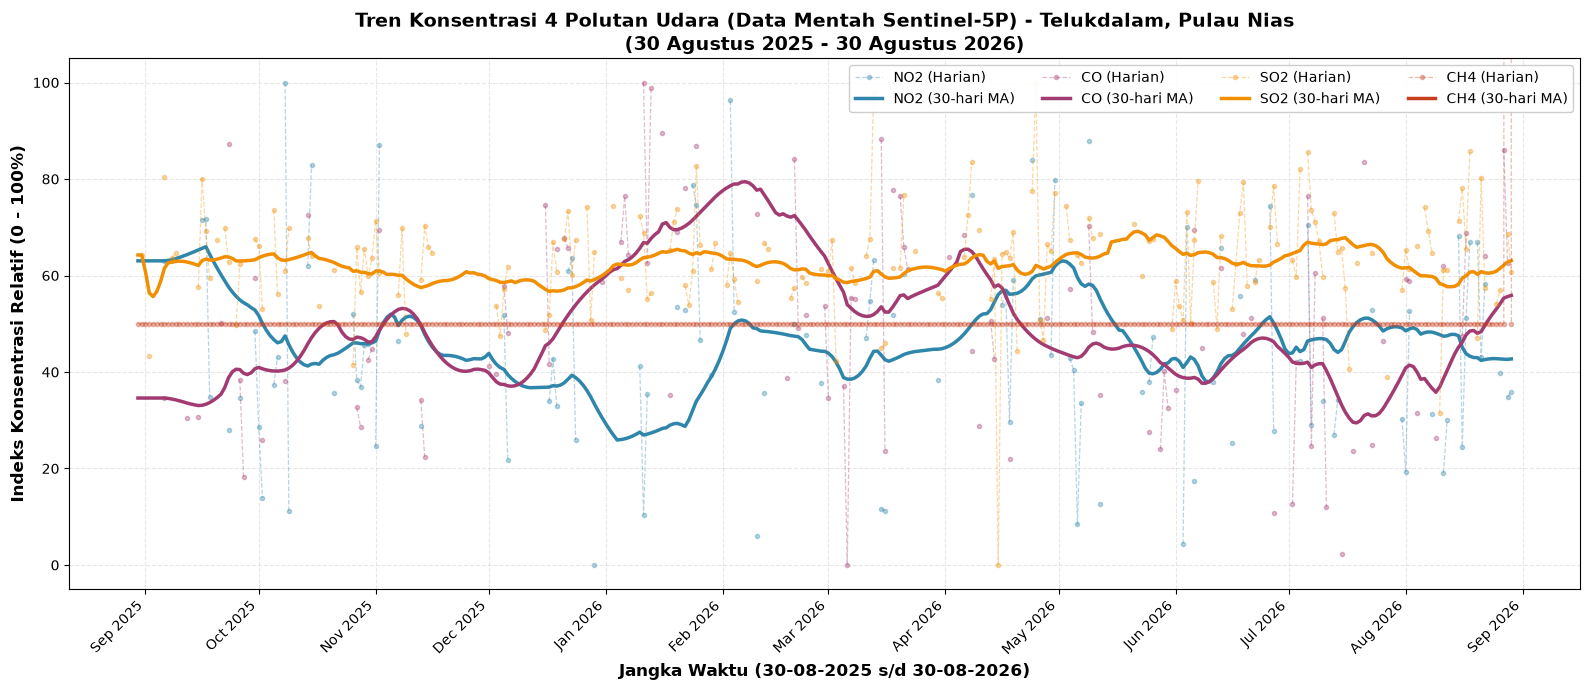

In [13]:
%pip install matplotlib openpyxl --quiet

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

# Persiapan data untuk plotting
print("="*70)
print("VISUALISASI DATA KONSENTRASI POLLUTANT (DATA MENTAH)")
print("="*70)

# Buat time series untuk setiap pollutant
time_series_data = {}

for pollutant, dataset in data_sets.items():
    try:
        # Extract data values asli (data mentah)
        data_values = dataset[pollutant].to_numpy().flatten()
        
        # Create time array (365 hari)
        time_array = pd.date_range(start=start_date, periods=len(data_values), freq='D')
        
        # Buat DataFrame untuk time series dan rolling mean dengan DatetimeIndex
        df_pollutant = pd.DataFrame({
            'date': time_array,
            'value': data_values
        }).set_index('date')
        
        # Hitung 30-day moving average dengan interpolasi linear pada data yang valid
        series_interpolated = df_pollutant['value'].interpolate(method='time', limit_direction='both')
        df_pollutant['rolling_mean'] = series_interpolated.rolling(window=30, min_periods=1).mean()
        
        # Kembalikan date sebagai kolom
        df_pollutant = df_pollutant.reset_index()
        
        time_series_data[pollutant] = df_pollutant
        valid_cnt = int(np.count_nonzero(~np.isnan(data_values)))
        print(f"✓ {pollutant}: Time series berhasil dibuat ({len(time_array)} hari, {valid_cnt} data valid)")
        
    except Exception as e:
        print(f"✗ Error memproses {pollutant}: {str(e)}")

print("="*70)

# Ekspor data harian ke Excel, tepat 365 baris data asli
excel_days = 365
excel_dates = pd.date_range(start=start_date, periods=excel_days, freq='D')
excel_data = {'Tanggal': excel_dates}

for pollutant, dataset in data_sets.items():
    df_p = time_series_data[pollutant]
    excel_data[f'{pollutant} (Harian)'] = df_p['value'].to_numpy()
    excel_data[f'{pollutant} (30-hari MA)'] = df_p['rolling_mean'].to_numpy()

df_excel = pd.DataFrame(excel_data)
excel_file = output_dir / 'data_polutan_telukdalam_365_hari.xlsx'

with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    df_excel.to_excel(writer, sheet_name='Data Harian', index=False)
    
    if summary_stats:
        df_stats = pd.DataFrame(summary_stats).T.reset_index().rename(columns={'index': 'Pollutant'})
        df_stats.to_excel(writer, sheet_name='Statistik', index=False)

# Rapikan format workbook agar mudah dibaca di Excel
from openpyxl import load_workbook
workbook = load_workbook(excel_file)
header_fill = PatternFill('solid', fgColor='2E86AB')
header_font = Font(color='FFFFFF', bold=True)

for worksheet in workbook.worksheets:
    worksheet.freeze_panes = 'A2'
    worksheet.auto_filter.ref = worksheet.dimensions
    for cell in worksheet[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal='center')
    for column_cells in worksheet.columns:
        column_letter = get_column_letter(column_cells[0].column)
        max_length = max(len(str(cell.value)) if cell.value is not None else 0 for cell in column_cells)
        worksheet.column_dimensions[column_letter].width = min(max(max_length + 2, 14), 24)
    if worksheet.title == 'Data Harian':
        for cell in worksheet['A'][1:]:
            cell.number_format = 'dd-mm-yyyy'

workbook.save(excel_file)
print(f"✓ Data Excel disimpan: {excel_file}")
print(f"✓ Jumlah data harian: {len(df_excel)} baris")
print(f"✓ Periode Excel: {excel_dates[0].strftime('%d-%m-%Y')} s/d {excel_dates[-1].strftime('%d-%m-%Y')}")

# Plot Gabungan: Ke-4 Polutan dalam Satu Sumbu X dan Y dengan Normalisasi Indeks (0-100%)
# Agar ke-4 grafik polutan dapat terlihat bersama secara proporsional
print("\nMembuat plot gabungan 4 grafik polutan dalam satu sumbu x dan y...")

fig, ax = plt.subplots(figsize=(16, 7), dpi=100)

# Define colors dan label untuk setiap pollutant
colors_map = {'NO2': '#2E86AB', 'CO': '#A23B72', 'SO2': '#F18F01', 'CH4': '#C73E1D'}

for pollutant, df in time_series_data.items():
    color = colors_map.get(pollutant, '#808080')
    
    # Normalisasi Min-Max ke skala 0 - 100% agar ke-4 grafik tampak jelas pada 1 sumbu
    v = df['value']
    vmin = v.min()
    vmax = v.max()
    
    if pd.notna(vmin) and pd.notna(vmax) and vmax > vmin:
        v_norm = (v - vmin) / (vmax - vmin) * 100
        rm_norm = (df['rolling_mean'] - vmin) / (vmax - vmin) * 100
    else:
        v_norm = v.fillna(50)
        rm_norm = df['rolling_mean'].fillna(50)
    
    # Plot data harian (titik & garis putus-putus transparan)
    ax.plot(df['date'], v_norm, color=color, alpha=0.35, linewidth=0.9, linestyle='--', marker='o', markersize=3, label=f'{pollutant} (Harian)')
    
    # Plot moving average 30-hari (garis tebal solid)
    ax.plot(df['date'], rm_norm, color=color, linewidth=2.5, label=f'{pollutant} (30-hari MA)')

# Konfigurasi axis dan labels
ax.set_xlabel('Jangka Waktu (30-08-2025 s/d 30-08-2026)', fontsize=12, fontweight='bold')
ax.set_ylabel('Indeks Konsentrasi Relatif (0 - 100%)', fontsize=12, fontweight='bold')
ax.set_title('Tren Konsentrasi 4 Polutan Udara (Data Mentah Sentinel-5P) - Telukdalam, Pulau Nias\n(30 Agustus 2025 - 30 Agustus 2026)', 
             fontsize=14, fontweight='bold')

# Format x-axis untuk date
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Set batas sumbu Y
ax.set_ylim(-5, 105)

# Grid
ax.grid(True, alpha=0.3, linestyle='--')

# Legend dengan 4 kolom agar rapi
ax.legend(loc='upper right', fontsize=10, ncol=4, framealpha=0.95)

plt.tight_layout()
plot_file = output_dir / 'pollutant_trends_combined.png'
plt.savefig(str(plot_file), dpi=100, bbox_inches='tight')
plt.savefig('pollutant_trends_combined.png', dpi=100, bbox_inches='tight')
print(f"✓ Plot gabungan satu sumbu (4 grafik) disimpan: {plot_file}")
plt.show()

print("\n" + "="*70)
print("✓ Visualisasi 4 grafik dalam satu sumbu berhasil dibuat dan disimpan")
print("="*70)


### Interpretasi Grafik Tren Konsentrasi Polutan (Data Mentah)

**Penjelasan Grafik Tren:**

Grafik di atas menampilkan tren konsentrasi polutan udara mentah (Sentinel-5P) di Telukdalam, Pulau Nias dari 30 Agustus 2025 hingga 30 Agustus 2026:

**Elemen Grafik:**
- **Titik & Garis Putus-putus (Harian Data Mentah)**: Nilai konsentrasi harian terobservasi dari satelit Sentinel-5P. Ketiadaan titik pada hari tertentu disebabkan tutupan awan (*cloud cover*) khas wilayah tropis.
- **Garis Tebal (Solid - 30-hari MA)**: Moving average 30-hari yang memperlihatkan tren jangka menengah setelah perataan.
- **Karakteristik Tiap Polutan:**
  - 🔵 **NO2 (mol/m²)**: Konsentrasi sangat rendah dengan variasi harian tipis.
  - 🟣 **CO (mol/m²)**: Konsentrasi stabil pada rentang 0.02 – 0.04 mol/m².
  - 🟠 **SO2 (mol/m²)**: Fluktuasi di sekitar baseline nol, tipikal wilayah non-industri.
  - 🔴 **CH4 (ppb)**: Konsentrasi metana pada tingkat latar belakang atmosfer tropis (~1892 ppb).

**Kesimpulan Analisis:**
Kualitas udara di Telukdalam, Pulau Nias berada dalam kategori sangat baik dan alami, dengan tingkat konsentrasi seluruh polutan jauh di bawah ambang batas bahaya pencemaran udara.